#Day 21 Prediksi Harga Mobil Bekas


Data dunia nyata jarang rapi. Notebook ini melatih keterampilan penting: **membersihkan data yang
berantakan** (kolom teks bercampur angka, satuan menempel, nilai hilang tersamar) lalu membangun
model **Random Forest Regressor** untuk memprediksi harga mobil bekas.

> 🎯 **Tujuan Pembelajaran**
> - Membersihkan kolom kotor: `Levy` ('-'→NaN), `Mileage` (' km'), `Engine volume` ('Turbo').
> - **Feature engineering**: membuat fitur `umur` mobil dari tahun produksi.
> - **Encoding** variabel kategorikal agar bisa dipakai model.
> - Membuang **outlier harga** yang ekstrem.
> - Melatih & mengevaluasi **RandomForestRegressor** (R²/MAE/RMSE).

##Tentang Dataset

**Car Price Prediction Challenge** — ~19.000 iklan mobil bekas dengan spesifikasi dan harganya.

- **Sumber:** [Kaggle — deepcontractor/car-price-prediction-challenge](https://www.kaggle.com/datasets/deepcontractor/car-price-prediction-challenge)

| Kolom | Catatan |
|-------|---------|
| `Price` | **Target**: harga mobil |
| `Levy` | Pajak — berisi `'-'` untuk yang kosong |
| `Mileage` | Jarak tempuh — berformat `"186005 km"` |
| `Engine volume` | Kapasitas mesin — kadang `"2.0 Turbo"` |
| `Prod. year` | Tahun produksi → kita ubah jadi **umur** |
| `Manufacturer`, `Category`, `Fuel type`, ... | Kategori (perlu encoding) |

## Import Library


- **pandas/numpy** → olah & bersihkan data.
- **matplotlib/seaborn** → visualisasi.
- **scikit-learn** → split data, `RandomForestRegressor`, metrik evaluasi.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

##Import Dataset

In [48]:
!pip install kaggle
!kaggle datasets download -d deepcontractor/car-price-prediction-challenge

Dataset URL: https://www.kaggle.com/datasets/deepcontractor/car-price-prediction-challenge
License(s): CC0-1.0
car-price-prediction-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)


In [49]:
!unzip car-price-prediction-challenge.zip

Archive:  car-price-prediction-challenge.zip
replace car_price_prediction.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: car_price_prediction.csv  


## Eksplorasi awal Dataset

In [50]:
df = pd.read_csv('/content/car_price_prediction.csv')
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [52]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,19237.0,4.557654e+07,936591.422799,20746880.0,45698374.0,45772308.0,45802036.0,45816654.0
Price,19237.0,1.855593e+04,190581.269684,1.0,5331.0,13172.0,22075.0,26307500.0
Prod. year,19237.0,2.010913e+03,5.668673,1939.0,2009.0,2012.0,2015.0,2020.0
Cylinders,19237.0,4.582991e+00,1.199933,1.0,4.0,4.0,4.0,16.0
Airbags,19237.0,6.582627e+00,4.320168,0.0,4.0,6.0,12.0,16.0


In [53]:
df.isna().sum().sum()

np.int64(0)

Interpretasi :

  - Data Kotor : `Levy` punya `'-'`, `Mileage` berisi teks `" km"`, `Engine volume` kadang ada `"Turbo"`. Semua ini harus dibersihkan sebelum model bisa belajar.
  - Banyak kolom bertipe `object`/string padahal seharusnya numerik (`Levy`, `Mileage`, `Engine volume`). Ini target utama pembersihan kita.

##Pembersihan Dataset & Feature Engineering

Kita kerjakan satu per satu sesuai catatan dataset.

### a) `Levy`: ganti `'-'` menjadi NaN, lalu jadikan angka

In [54]:
df = df.copy()
#ubah nilai - menjadi NaN
df['Levy'] = df['Levy'].astype(str).str.strip().replace('-', np.nan)
df['Levy'] = pd.to_numeric(df['Levy'], errors='coerce')

#Imputasi nilai NaN dengan nilai median
df['Levy'] = df['Levy'].fillna(df['Levy'].median())


print(df['Levy'].isna().sum())
df['Levy'].head()

0


,Levy
0,1399.0
1,1018.0
2,781.0
3,862.0
4,446.0


Interpretasi:
-  Tanda `'-'` sebenarnya berarti "tidak ada data pajak", jadi kita ubah ke NaN lalu isi dengan median agar tidak membuang baris.
- Kini `Levy` siap dipakai sebagai fitur numerik.

### b)  `Mileage`: hapus `" km"` dan ubah ke angka

In [55]:
df["Mileage"] = (df["Mileage"].astype(str)
                  .str.replace(" km", "", regex=False)
                  .str.replace(",", "", regex=False))
df["Mileage"] = pd.to_numeric(df["Mileage"], errors="coerce")
print("Mileage contoh:", df["Mileage"].head(3).tolist())

Mileage contoh: [186005, 192000, 200000]


Interpretasi:
- Satuan `" km"` adalah teks yang menempel pada angka. Setelah dihapus, jarak tempuh menjadi numerik dan bisa dibandingkan antar mobil.

### c) `Engine volume`: pisahkan info `"Turbo"` menjadi fitur biner

In [56]:
df["Turbo"] = df["Engine volume"].astype(str).str.contains("Turbo").astype(int)
df["Engine volume"] = (df["Engine volume"].astype(str)
                       .str.replace("Turbo", "", regex=False)
                       .str.strip())
df["Engine volume"] = pd.to_numeric(df["Engine volume"], errors="coerce")
print("Mobil dengan turbo:", df["Turbo"].sum())

Mobil dengan turbo: 1931


Interpretasi:
  -  Kata `"Turbo"` mengandung informasi berharga (mesin turbo biasanya lebih mahal), jadi kita tidak buang — melainkan jadikan **fitur biner `Turbo`** terpisah, lalu kapasitas mesin
diubah ke angka murni.

### d) `umur` mobil dari `Prod. year`

In [57]:
#cari mobil paling muda dulu baru dikurangi prod.year
df['Prod. year'].max()

2020

In [58]:
df['age_car'] = 2020 - df['Prod. year']
df['age_car'].head()

,age_car
0,10
1,9
2,14
3,9
4,6


### e) Buang outlier harga ekstrem

`Price` punya nilai aneh (dari 1 hingga puluhan juta). Kita batasi ke rentang wajar memakai **persentil 1%–99%** agar model tidak terganggu pencilan.

In [59]:
print(f"harga terendah: {df['Price'].min()}")
print(f"harga tertinggi: {df['Price'].max()}")

harga terendah: 1
harga tertinggi: 26307500


In [60]:
max_up = df['Price'].quantile(0.99)
min_down = df['Price'].quantile(0.01)
df = df[(df['Price'] <= max_up) & (df['Price'] >= min_down)]


df = df[df['Price']>100]

In [61]:
print(f"harga terendah: {df['Price'].min()}")
print(f"harga tertinggi: {df['Price'].max()}")

print(f"sisa baris:{len(df)}")

harga terendah: 110
harga tertinggi: 84675
sisa baris:18669


Interpretasi:
- Outlier harga (mobil seharga 1 atau 26 juta) bisa menyesatkan model.
- Setelah dipangkas, rentang harga menjadi realistis dan model akan belajar dari pola yang representatif.

### f) Bersihkan sisa missing value dan kolom yang tidak digunakan

In [62]:
#drop kolom yang tidak dipakai
df = df.drop(columns=["ID"])
df = df.dropna(subset=["Engine volume", "Mileage"])


print(f"Missing value: {df.isna().sum().sum()}")
print(f"sisa baris:{len(df)}")

Missing value: 0
sisa baris:18669


Interpretasi:
  - `ID` hanya nomor unik (tak ada nilai prediktif) sehingga dibuang.
  - Baris dengan kapasitas mesin/jarak tempuh yang gagal di-parse juga dibuang. Data kini bersih.

## EDA dan Visualisasi

### a) Distribusi Harga ( setelah dibersihkan )

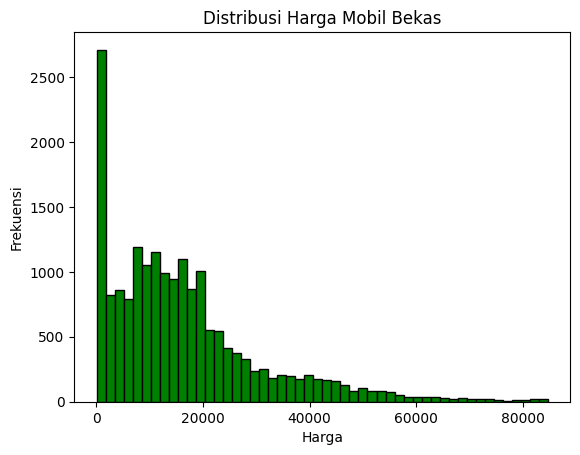

In [68]:
plt.hist(df['Price'],
         bins=50,
         color="green",
         edgecolor="black")
plt.xlabel('Harga')
plt.ylabel('Jumlah Mobil')
plt.title('Distribusi Harga Mobil Bekas')
plt.show()

Interpretasi:
- Distribusi harga miring ke kanan
- banyak mobil murah dan sedikit mobil yang mahal
- pola yang reasonalbe untuk pasar mobil bekas

### b) Umur vs Harga dan Mobil yang disertai Turbo

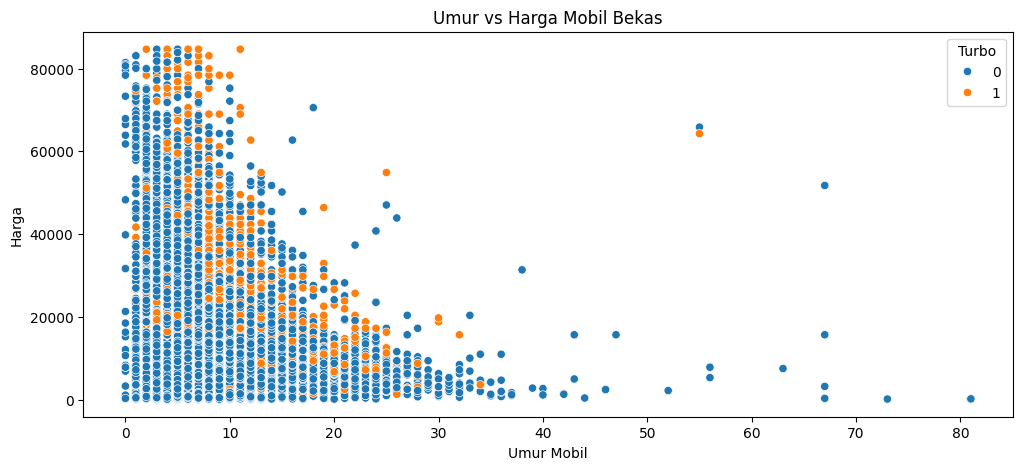

In [70]:
plt.figure(figsize=(12,5))

sns.scatterplot(df, x='age_car', y='Price', hue='Turbo')
plt.xlabel('Umur Mobil')
plt.ylabel('Harga')
plt.title('Umur vs Harga Mobil Bekas')
plt.show()

Interpretasi:
  -  Terlihat tren menurun: mobil yang lebih tua cenderung lebih murah. Tapi hubungannya **non-linear** (penurunan cepat di awal lalu melandai) — Random Forest cocok menangani ini.
  - Mobil yang disertai Turbo pada bagian mesinnya terlihat mendominasi harga, Cenderung lebih tinggi harganya dengan mobil tahun yang sama

### c) harga rata rata per jenis bahan bakar

In [72]:
mean_fuel = df.groupby('Fuel type')['Price'].mean().sort_values()
mean_fuel.sort_values(ascending=False)

,Price
Fuel type,
Diesel,22950.868248
Plug-in Hybrid,22872.423529
Hydrogen,20385.000000
Petrol,16340.210338
LPG,13551.647260
Hybrid,11037.435498
CNG,8561.338086


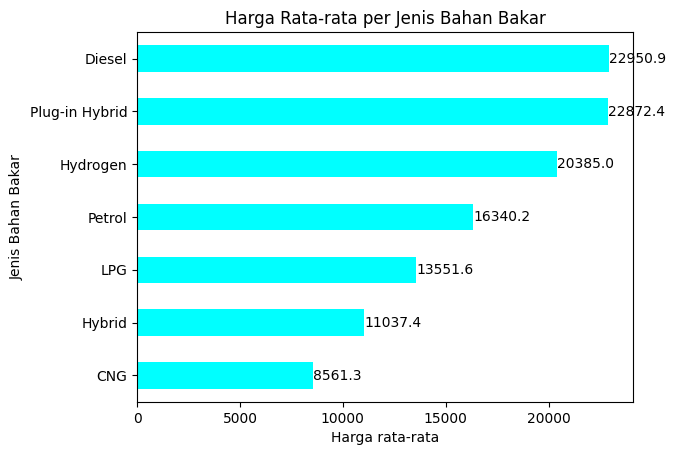

In [81]:
mean_fuel.plot(kind="barh", color="cyan")
plt.xlabel('Harga rata-rata')
plt.ylabel('Jenis Bahan Bakar')
plt.title('Harga Rata-rata per Jenis Bahan Bakar')
for i, v in enumerate(mean_fuel):
    plt.text(v,
             i,
             str(round(v, 1)),
             color='black',
             va='center')
plt.show()

Interpretasi:
-   Beberapa jenis bahan bakar (mis. hybrid/diesel tertentu) dikaitkan dengan harga rata-rata lebih tinggi.
-  Ini menegaskan `Fuel type` adalah fitur kategorikal yang berguna. dan bisa digunakan menjadi salah 1 feature


## Preprocessing - Encoding Data kategorical

- Model tidak bisa membaca teks.
- Ubah kolom kategorikal menjadi angka.
- Kolom dengan **banyak kategori unik** (`Model`) kita buang agar one-hot tidak meledak; sisanya kita **one-hot encode**
dengan `pd.get_dummies`.

In [86]:
target = "Price"

In [87]:
#buang kolom denga kardinalitas tinggi dan yang sudah dioleh
fitur_df = df.drop(columns=["Model","Prod. year"])


#Encode kolom kategorical
cat_col = fitur_df.select_dtypes(include="object").columns.tolist()
print("kolom kategorikal:", cat_col)


fitur_df = pd.get_dummies(fitur_df, columns=cat_col, drop_first=True)
print("kolom setelah encoding:", fitur_df.shape[1])


kolom kategorikal: ['Manufacturer', 'Category', 'Leather interior', 'Fuel type', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color']
kolom setelah encoding: 110


In [88]:
fitur_df.head()

,Price,Levy,Engine volume,Mileage,Cylinders,Airbags,Turbo,age_car,Manufacturer_ALFA ROMEO,Manufacturer_ASTON MARTIN,...,Color_Green,Color_Grey,Color_Orange,Color_Pink,Color_Purple,Color_Red,Color_Silver,Color_Sky blue,Color_White,Color_Yellow
0,13328,1399.0,3.5,186005,6.0,12,0,10,False,False,...,False,False,False,False,False,False,True,False,False,False
1,16621,1018.0,3.0,192000,6.0,8,0,9,False,False,...,False,False,False,False,False,False,False,False,False,False
2,8467,781.0,1.3,200000,4.0,2,0,14,False,False,...,False,False,False,False,False,False,False,False,False,False
3,3607,862.0,2.5,168966,4.0,0,0,9,False,False,...,False,False,False,False,False,False,False,False,True,False
4,11726,446.0,1.3,91901,4.0,4,0,6,False,False,...,False,False,False,False,False,False,True,False,False,False


Interpretasi:
- `pd.get_dummies` mengubah tiap kategori menjadi kolom 0/1.
- `drop_first=True` menghindari redundansi.
- `Model` dibuang karena ratusan nilai uniknya akan membuat fitur membengkak tanpa banyak manfaat untuk model pohon.

##Data Splitting

In [89]:
X = fitur_df.drop(columns=[target])
y = fitur_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [90]:
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (14935, 109)
X_test: (3734, 109)
y_train: (14935,)
y_test: (3734,)


Interpretasi:
-  Data dibagi 80/20. Model belajar dari data latih dan dievaluasi pada data uji yang belum dilihat.

## Modeling - Random Forest Regressir

**Random Forest** menggabungkan banyak pohon keputusan (decision tree) dan merata-ratakan prediksinya.
- Keunggulannya: menangani hubungan **non-linear** dan interaksi antar fitur secara otomatis, serta tahan terhadap outlier yang tersisa.

In [91]:
#tentukan model dan parameter model
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=30,
    random_state=42,
    n_jobs=1)

#latih dengan data latih
model.fit(X_train, y_train)

#hitung prediksi dengan data fitur X_test
y_pred = model.predict(X_test)

Interpertasi:
- Dengan 100 pohon, model cukup stabil.
- Maksimal kedalaman pohon = 30
- random_state = 42, untuk reproduktivitas
- Kita memakai `n_jobs=1` agar berjalan andal di semua sistem; bila CPU-mu banyak inti, `n_jobs=-1` bisa mempercepat pelatihan
(namun di sebagian lingkungan Windows ia rentan error, jadi kita pilih yang paling aman).

## Evaluasi

### a) Metrik R², MAE, RMSE

In [93]:
r2_sc = r2_score(y_test, y_pred)
mae_sc = mean_absolute_error(y_test, y_pred)
rmse_sc = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R^2: {r2_sc:.2f}")
print(f"MAE: {mae_sc:.2f}")
print(f"RMSE: {rmse_sc:.2f}")

R^2: 0.78
MAE: 3659.63
RMSE: 6757.82


Interpretasi:
- Model mampu menjelaskan 78% variasi dari keseluruhan dataset
- Secara rata-rata, prediksi harga mobil dari model meleset (baik di atas maupun di bawah) sekitar 3,659.63 unit dari harga aktualnya
- Perhatikan bahwa nilai RMSE (6,757.82) jauh lebih besar daripada MAE (3,659.63). Dalam statistik, perbedaan yang cukup besar ini mengindikasikan adanya beberapa outlier (pencilan) atau kesalahan prediksi yang sangat besar pada beberapa data tertentu

### b) Prediksi vs Aktual

/tmp/ipykernel_1351/1896817692.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


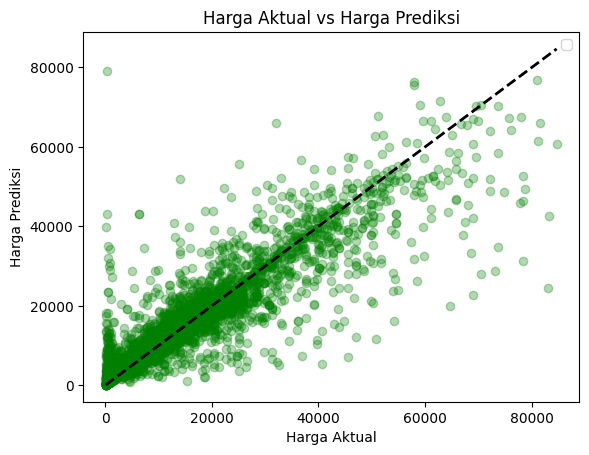

In [102]:
plt.scatter(y_test, y_pred, alpha= 0.3, color="green")


lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'k--',  linewidth=2)
plt.xlabel('Harga Aktual')
plt.ylabel('Harga Prediksi')
plt.title('Harga Aktual vs Harga Prediksi')
plt.legend()
plt.show()

Interpretasi:
- Titik-titik mengelompok di sekitar garis diagonal hitam, menandakan prediksi yang cukup akurat.
- Sebaran melebar pada harga tinggi adalah hal lumrah karena mobil mahal lebih bervariasi.

### c) Diagnostik Residual

In [112]:
def plot_residual(y_true, y_pred, figsize=(12, 4)):
    """Gambar diagnostik residual: scatter (residual vs prediksi) + histogram.

    Untuk model linear yang sehat, residual harus tersebar **acak di sekitar nol**
    tanpa pola, dan histogramnya mendekati lonceng (normal). Pola melengkung =
    sinyal hubungan non-linear yang belum tertangkap.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    residual = np.asarray(y_true) - np.asarray(y_pred)
    fig, ax = plt.subplots(1, 2, figsize=figsize)

    ax[0].scatter(y_pred, residual, alpha=0.5, color="#8E44AD")
    ax[0].axhline(0, color="red", linestyle="--", linewidth=2)
    ax[0].set_title("Residual vs Prediksi")
    ax[0].set_xlabel("Nilai prediksi")
    ax[0].set_ylabel("Residual (aktual - prediksi)")

    ax[1].hist(residual, bins=30, color="#5DADE2", edgecolor="white")
    ax[1].axvline(0, color="red", linestyle="--", linewidth=2)
    ax[1].set_title("Distribusi Residual")
    ax[1].set_xlabel("Residual")
    ax[1].set_ylabel("Frekuensi")

    plt.tight_layout()
    plt.show()
    return residual


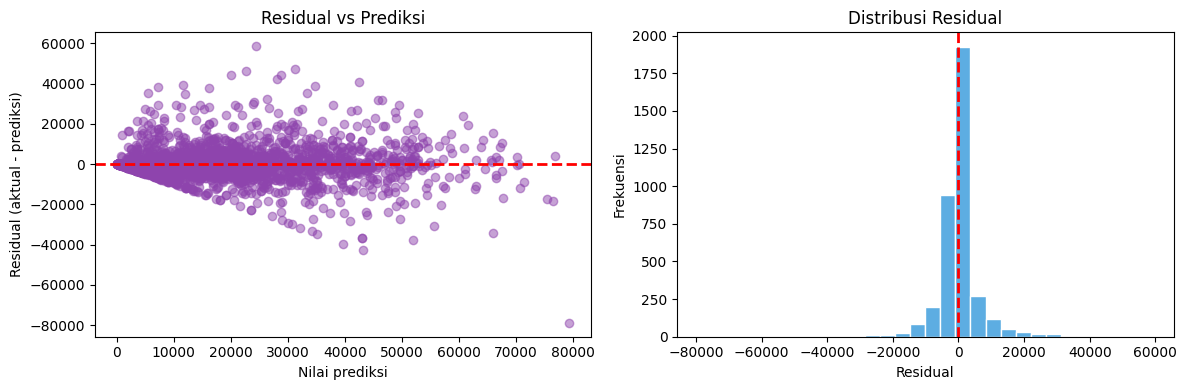

In [113]:
_ = plot_residual(y_test, y_pred)

1. Grafik Kiri: Residual vs Prediksi (Residual vs Predicted)Grafik ini digunakan untuk mendeteksi pola error dan asumsi homoskedastisitas pada model regresi.

    - Pola Penyebaran (Heteroskedastisitas): Idealnya, titik-titik ungu tersebar secara acak dan merata di sekitar garis merah ($y = 0$). Namun, pada grafik ini terlihat adanya pola di mana sebaran error tidak konstan (cenderung melebar atau membentuk pola tertentu seiring bertambahnya nilai prediksi). Hal ini mengindikasikan adanya heteroskedastisitas, yaitu varians error model berubah pada tingkat nilai prediksi yang berbeda.

   - Pencilan Ekstrem (Outlier): Terdapat satu titik outlier yang sangat mencolok di pojok kanan bawah (nilai prediksi sekitar 80.000 dengan residual mendekati -80.000). Ini menunjukkan ada satu data observasi tertentu yang membuat model meleset sangat jauh (prediksinya terlampau tinggi dibandingkan nilai aktualnya).
  
2. Grafik Kanan: Distribusi Residual (Residual Distribution)Grafik histogram ini menunjukkan seberapa sering nilai residual (error) tertentu muncul.

   - Pemusatan Error: Sebagian besar residual terkonsentrasi sangat tinggi di sekitar angka 0 (ditandai oleh garis vertikal merah). Ini adalah tanda yang baik, yang berarti sebagian besar prediksi model sudah sangat mendekati nilai aktualnya.
  
    - Bentuk Distribusi: Distribusi tampak sangat menumpuk di tengah dengan puncak yang tinggi (leptokurtik). Meskipun berpusat di dekat nol, bentuknya tidak sepenuhnya menyerupai kurva lonceng normal yang mulus, yang memperkuat indikasi adanya sisa-sisa error atau pencilan yang perlu diteliti lebih lanjut pada data Anda.

### d) Feature Importance — fitur apa yang paling menentukan harga?

In [105]:
ftr_imp = pd.Series(model.feature_importances_,
                    index=X_train.columns).sort_values(ascending=False).head(10)
ftr_imp.head(10)

,0
age_car,0.212283
Airbags,0.116830
Mileage,0.115564
Engine volume,0.098406
Fuel type_Diesel,0.072685
Gear box type_Tiptronic,0.071480
Levy,0.057650
Drive wheels_Front,0.029770
Turbo,0.020937
Leather interior_Yes,0.018713


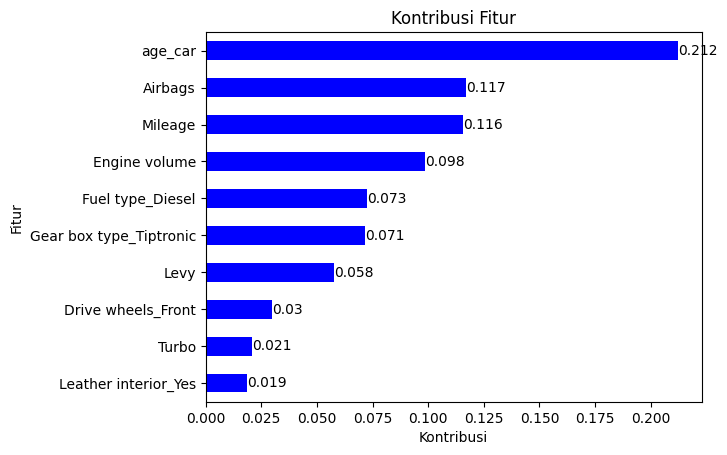

In [111]:
ftr_imp.sort_values().plot(kind="barh", color="blue")


for i, v in enumerate(ftr_imp.sort_values()):
    plt.text(v,
             i,
             str(round(v, 3)),
             color='black',
             va='center')
plt.xlabel('Kontribusi')
plt.ylabel('Fitur')
plt.title('Kontribusi Fitur')
plt.show()


Interpretasi:
-  Fitur seperti **`age`, `Mileage` (jarak tempuh), `Engine volume`, dan `Levy`** biasanyamendominasi — sesuai intuisi: mobil yang lebih muda, jarak tempuh rendah, dan mesin lebih besar cenderung lebih mahal.

## Kesimpulan & Insight

- Data mobil bekas sangat "kotor"; **pembersihan** (Levy, Mileage, Engine volume) adalah kunci.
- **Feature engineering** (`umur`, fitur `Turbo`) menambah sinyal yang berguna.
- Membuang **outlier harga** membuat model lebih representatif.
- **Random Forest** menangkap pola non-linear dengan baik (R² jauh lebih tinggi daripada model linear sederhana).
- Faktor harga terpenting: **umur, jarak tempuh, dan kapasitas mesin**.

Insight bisnis: untuk menaksir harga mobil bekas, prioritaskan data **umur, kilometer, dan spesifikasi
mesin** — ketiganya membawa porsi terbesar dalam keputusan harga.